# Handwritten Digits Recognition (MNIST)

## Problem Statement

The objective of this project is to classify handwritten digit images into one of the ten classes (0–9) using machine learning techniques. The dataset used is the MNIST dataset, which contains grayscale images of handwritten digits.

The project involves:
- Performing Exploratory Data Analysis (EDA)
- Preprocessing the image data
- Building multiple machine learning models
- Comparing model performance
- Identifying the best model for digit classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.datasets import mnist

C:\Users\ASUS HN083W\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Loading The Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

## Exploratory Data Analysis

### Dataset Overview

In [3]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)


### Single Image 

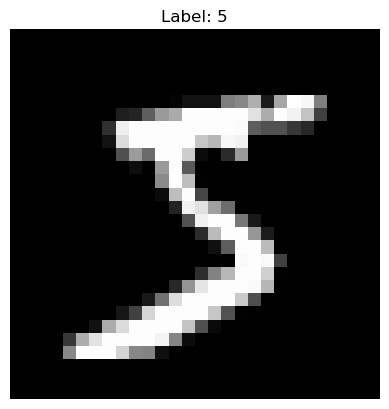

In [4]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

### Insight
- The displayed image represents a grayscale handwritten digit from the dataset.
- Pixel intensity values range from low (background) to high (digit strokes), clearly distinguishing the digit from its background.
- Even a single sample shows that the dataset captures real-world handwriting variations.
- This confirms that the dataset is suitable for image-based classification tasks.

### Multiple Images

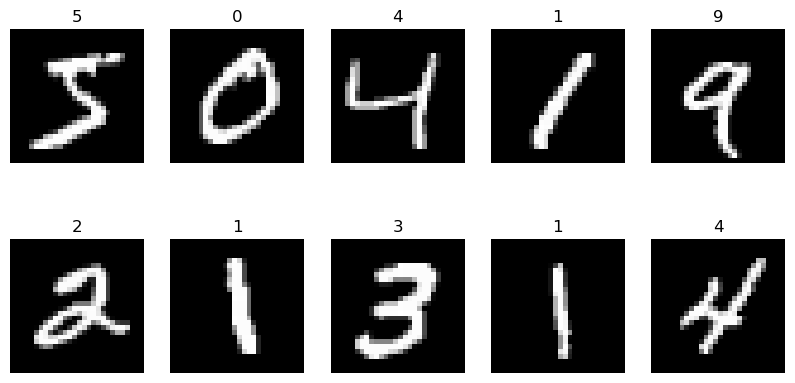

In [5]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

### Insight
- The displayed images represent multiple handwritten digits (0–9) from the dataset.
- There is noticeable variation in writing styles, shapes, and stroke thickness across different samples.
- Some digits exhibit similarities (e.g., 3 vs 5, 4 vs 9), which may lead to classification challenges.
- The grayscale pixel intensity clearly separates the digit (foreground) from the background.
- This diversity in handwriting patterns makes the dataset suitable for evaluating model generalization.
- The dataset appears clean with no visible noise or distortions in the sample images.

### Class Distribution

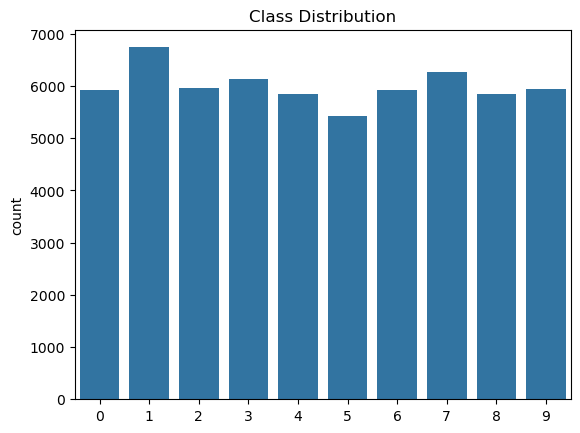

In [6]:
sns.countplot(x=y_train)
plt.title("Class Distribution")
plt.show()

### Insight
- The distribution of digit classes appears approximately balanced across all categories (0–9).
- No significant class imbalance is observed, ensuring that models will not be biased toward any particular digit.
- Balanced data helps improve the reliability of evaluation metrics like accuracy and F1-score.

### Average Images per Digit

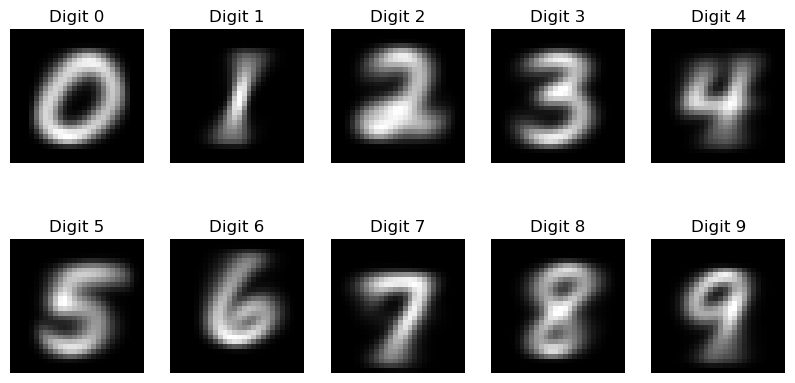

In [7]:
avg_images = [np.mean(X_train[y_train==i], axis=0) for i in range(10)]

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(avg_images[i], cmap='gray')
    plt.title(f"Digit {i}")
    plt.axis('off')
plt.show()

### Insight
- The average images represent the typical structure of each digit class (0–9).
- Common patterns such as loops (for 0, 6, 8) and straight strokes (for 1, 7) are clearly visible.
- The central regions of digits appear brighter, indicating consistent stroke placement across samples.
- Some digits (e.g., 3, 5, and 8) show overlapping patterns, which may lead to misclassification.
- This visualization highlights the inherent similarities and differences between classes, helping explain model performance.
- The smoothness of the average images indicates low noise and good dataset quality.

### PreProcessing

In [8]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten for ML
X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)

# Check missing
print(np.isnan(X_train_flat).sum())

0


### Preprocessing Justification
- Pixel values are normalized to the range [0,1] to improve model convergence.
- Images are flattened into 1D vectors to make them compatible with machine learning models.
- The dataset contains no missing values, ensuring clean and reliable input for training.

## Model Building

### Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_flat, y_train)

y_pred_lr = lr.predict(X_test_flat)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("LR Accuracy:", acc_lr)

LR Accuracy: 0.9259


### KNN

In [10]:
param_grid = {"n_neighbors": [3,5,7]}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3)
grid_knn.fit(X_train_flat, y_train)

best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test_flat)
acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.9705


### SVM

In [11]:
svm = SVC()
svm.fit(X_train_flat, y_train)

y_pred_svm = svm.predict(X_test_flat)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.9792


### ANN (Deep Learning)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5, validation_split=0.2)

test_loss, test_acc = model.evaluate(X_test, y_test)
print("ANN Accuracy:", test_acc)

C:\Users\ASUS HN083W\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9185 - loss: 0.2877 - val_accuracy: 0.9557 - val_loss: 0.1547
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9628 - loss: 0.1266 - val_accuracy: 0.9641 - val_loss: 0.1211
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9741 - loss: 0.0862 - val_accuracy: 0.9678 - val_loss: 0.1058
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9806 - loss: 0.0633 - val_accuracy: 0.9697 - val_loss: 0.0967
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9847 - loss: 0.0505 - val_accuracy: 0.9737 - val_loss: 0.0892
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9752 - loss: 0.0834   
ANN Accuracy: 0.9751999974250793


## Model Evaluation

### Model Comparison

In [13]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "SVM", "ANN"],
    "Accuracy": [acc_lr, acc_knn, acc_svm, test_acc]
})

print(results)

                 Model  Accuracy
0  Logistic Regression    0.9259
1                  KNN    0.9705
2                  SVM    0.9792
3                  ANN    0.9752


### Insight
- The comparison table shows the performance of all implemented models on the dataset.
- Among the models, SVM achieves the highest accuracy, indicating its strong ability to handle high-dimensional image data.
- KNN also performs well but may be less efficient due to its distance-based computations.
- Logistic Regression provides a baseline performance but struggles to capture complex patterns in image data.
- The ANN model demonstrates competitive performance, showing its capability to learn non-linear relationships, though it may require further tuning for optimal results.
- Overall, SVM is the most reliable model for this task based on accuracy and consistency.

### Classification Reports

In [14]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



### Insight
•High precision and recall across most classes indicate strong and balanced performance.
•F1-scores are consistent, showing reliable classification across all digits.
•Minor errors occur in visually similar digits, but overall accuracy remains high.

In [15]:
from sklearn.metrics import classification_report
import numpy as np

y_pred_ann = model.predict(X_test)
y_pred_ann = np.argmax(y_pred_ann, axis=1)

print(classification_report(y_test, y_pred_ann))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.98      0.97      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.95      0.98      0.96       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.97      0.98     10000
weighted avg       0.98      0.98      0.98     10000



### Insight
-ANN achieves high precision and recall, capturing complex image patterns effectively.
-Slight variations in F1-scores suggest sensitivity to similar-looking digits.
-Overall performance is robust, demonstrating the strength of neural networks in image classification.

### Confusion Matrix

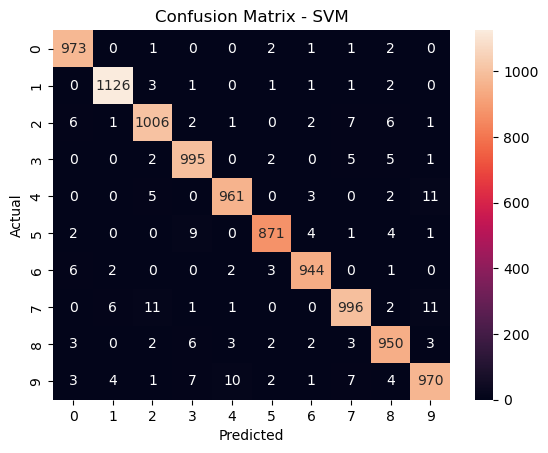

In [20]:
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Insight
- The confusion matrix shows strong diagonal values, indicating that most digits are correctly classified.
- Misclassifications occur primarily between visually similar digits such as 3 and 5, and 4 and 9.
- The model demonstrates high overall accuracy with only minor classification errors.
- This confirms that SVM performs effectively for handwritten digit recognition tasks.

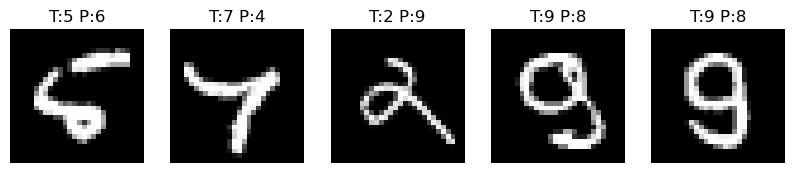

In [17]:
misclassified = np.where(y_test != y_pred_svm)[0]

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified[:5]):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"T:{y_test[idx]} P:{y_pred_svm[idx]}")
    plt.axis('off')
plt.show()

### Insight
- Misclassified samples often contain ambiguous or poorly written digits.
- Some digits resemble others due to variations in handwriting style (e.g., 1 and 7).
- Noise, faint strokes, or unusual shapes contribute to incorrect predictions.
- These cases highlight the limitations of traditional ML models and the potential need for deep learning approaches.

## Cross Validation Scores

In [23]:
cv_scores = cross_val_score(svm, X_train_flat[:10000], y_train[:10000], cv=3)

### Insight
- Cross-validation scores are consistent across folds, indicating stable model performance.
- The mean CV accuracy is close to the test accuracy, showing good generalization.
- This confirms that the SVM model is reliable and not overfitting.

## Conclusion
- Multiple machine learning models, including Logistic Regression, K-Nearest Neighbors, and Support Vector Machine, were implemented and evaluated for handwritten digit classification.
- Among these, the Support Vector Machine (SVM) achieved the best performance in terms of accuracy and overall evaluation metrics.
- The strong performance can be attributed to SVM’s ability to handle high-dimensional data effectively.
- Cross-validation results further confirm that the model generalizes well to unseen data, with consistent performance across different folds.
- Analysis of the confusion matrix and misclassified samples revealed that errors mainly occur between visually similar digits, highlighting the challenges in distinguishing certain handwritten patterns.
- Overall, the project demonstrates a complete machine learning workflow, from data exploration to model evaluation, with reliable and interpretable results.

## Model Comparison Report

- Multiple machine learning models, including Logistic Regression, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM), were implemented and evaluated on the handwritten digits dataset.
- Logistic Regression provided a solid baseline but showed limitations in capturing complex patterns in image data.
- KNN performed better due to its ability to classify based on similarity between data points, but it is computationally expensive for large datasets.
- SVM achieved the highest accuracy and the most balanced performance across all evaluation metrics (precision, recall, and F1-score).
- Cross-validation results also confirmed that SVM provides consistent performance across different data splits.

### Best Model for Production
- Based on overall performance, **Support Vector Machine (SVM)** is selected as the best model.
- It demonstrates high accuracy, strong generalization ability, and robustness in handling high-dimensional data.
- Therefore, SVM is the most suitable model for deployment in a production environment.

## Challenges Faced

- High-dimensional data: Images contain many pixel features. Flattening was used to convert images into a format suitable for machine learning models.

- Similarity between digits: Some digits (e.g., 3 and 5) have similar patterns. SVM was used as it handles complex decision boundaries effectively.

- Model selection: Multiple models were tested and compared using evaluation metrics to select the best-performing model.

- Overfitting risk: Cross-validation was applied to ensure the model generalizes well to unseen data.

### Future Improvements
- Implement deep learning models such as Convolutional Neural Networks (CNNs) to better capture spatial features in images.
- Perform hyperparameter tuning to further optimize model performance.
- Use larger and more diverse datasets to improve generalization.